<a href="https://colab.research.google.com/github/marinacornelius/base-para-agentes-de-IA/blob/main/Tutorial_Agente_de_triagem_m%C3%A9dica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Agente de triagem médica

### Escopo: agente de IA que realiza triagem médica de pacientes.
**Requisitos:**
  1. Lê um protocolo_triagem.txt que relaciona sintomas com a gravidade de atendimento (Azul, Verde, Amarelo, Vermelho).
  2. Agenda uma consulta para uma especialidade, informando a urgência e a data preferencial.
  3. Se o caso for muito grafe, aciona a emergência local.
  4. O agente NUNCA dá um diagnóstico médico ou sugere remédios, ele deve sempre sugerir um médico.

## Setup e Libs

In [1]:
!pip install -qU langchain langgraph langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.8/173.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 12.4 MB/s eta 0:00:00


In [2]:
from google.colab import userdata
import os

os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')

## Criando o protocolo .txt

In [12]:
# Cria o arquivo de protocolo que o agente terá que ler
protocolo = """
PROTOCOLO DE TRIAGEM HOSPITALAR - CLASSIFICAÇÃO DE RISCO:

1. VERMELHO (Emergência Absoluta):
- Sintomas: Dor no peito intensa irradiando para o braço, falta de ar severa, perda de consciência, sangramento abundante, convulsão ativa.
- Ação Exigida: Acionar emergência local imediatamente. NUNCA agendar consulta.

2. AMARELO (Urgência):
- Sintomas: Febre alta (>39°C) persistente, dor abdominal intensa, vômitos que não cessam, tontura forte.
- Ação Exigida: Direcionar para o pronto-socorro mais próximo.

3. VERDE / AZUL (Pouco Urgente / Não Urgente):
- Sintomas: Dor de cabeça leve, coriza, tosse leve, dor muscular, febre baixa (<38°C).
- Ação Exigida: Agendar consulta médica regular para os próximos dias.
"""

with open("protocolo_triagem.txt", "w", encoding="utf-8") as f:
    f.write(protocolo)

print("✅ Arquivo 'protocolo_triagem.txt' gerado com sucesso para o RAG!")

✅ Arquivo 'protocolo_triagem.txt' gerado com sucesso para o RAG!


## Criando as tools

In [10]:
from langchain_core.tools import tool

@tool
def consultar_protocolo_triagem() -> str:
    """
    Usa esta ferramenta para ler o protocolo de triagem do hospital.
    Você DEVE usar esta ferramenta ANTES de tomar qualquer decisão sobre agendamento ou emergência.
    Ela não recebe nenhum argumento e retorna o protocolo de triagem.
    """
    with open("protocolo_triagem.txt", "r", encoding="utf-8") as f:
        return f.read()

@tool
def agendar_consulta(especialidade: str, urgencia: str, data_preferencial: str) -> str:
    """
    Usa esta ferramenta APENAS para agendar consultas de casos classificados como VERDE ou AZUL.

    Args:
        especialidade: A especialidade médica (ex: Clinico Geral, Ortopedista).
        urgencia: A cor da classificação de risco (VERDE ou AZUL).
        data_preferencial: A data ou período que o paciente deseja (ex: "próxima semana").
    """
    return f"Sucesso: Consulta com {especialidade} agendada para {data_preferencial} (Classificação: {urgencia})."

@tool
def acionar_emergencia_local(tipo_emergencia: str, endereco: str) -> str:
    """
    Usa esta ferramenta APENAS para casos críticos classificados como VERMELHO.
    Esta ferramenta despacha uma ambulância imediatamente.

    Args:
        tipo_emergencia: Descrição breve do risco de morte.
        endereco: O local onde o paciente está.
    """
    return f"ALERTA CRÍTICO: Ambulância despachada para {endereco} por motivo de {tipo_emergencia}."

## Criando o agente - LangGraph

In [5]:
# 0. Define o System Prompt
system_prompt = """
Você é o Assistente Virtual de Triagem do Hospital Central.
Seu objetivo é escutar os sintomas do paciente, consultar o protocolo de triagem e usar a ferramenta adequada.

GUARDRAILS CRÍTICOS:
1. Você NUNCA, em hipótese alguma, pode dar um diagnóstico médico (ex: "parece que você está com gripe").
2. Você NUNCA pode sugerir medicamentos, chás ou tratamentos.
3. Se o usuário pedir um diagnóstico ou perguntar qual remédio tomar, você deve BLOQUEAR a ação e responder EXATAMENTE:
   "Sou um assistente virtual de triagem e não tenho licença para fornecer diagnósticos ou prescrições médicas. Por favor, aguarde a avaliação médica."
"""

In [6]:
from typing import Literal
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import SystemMessage
from langgraph.checkpoint.memory import MemorySaver

# Add a memória
memory = MemorySaver()

# 1. Inicializa o LLM e as Tools
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
tools = [consultar_protocolo_triagem, agendar_consulta, acionar_emergencia_local]

# Vincula as ferramentas diretamente à API do Gemini (Tool Calling nativo)
llm_with_tools = llm.bind_tools(tools)

# 2. Define a função do nó principal
def call_model(state: MessagesState):
    # Recupera o histórico de mensagens
    messages = state["messages"]

    # Garante que o system_prompt esteja sempre no início do contexto
    if not any(isinstance(m, SystemMessage) for m in messages):
        messages = [SystemMessage(content=system_prompt)] + messages

    # O Gemini avalia se precisa chamar uma tool ou se pode responder diretamente
    response = llm_with_tools.invoke(messages)

    # Retorna a resposta anexada ao estado
    return {"messages": [response]}

# 3. Define a função de roteamento (Condicional)
def should_continue(state: MessagesState) -> Literal["tools", END]:
    messages = state["messages"]
    last_message = messages[-1]

    # Se a resposta do LLM contiver uma requisição para chamar uma tool, vai para o nó de tools
    if last_message.tool_calls:
        return "tools"

    # Se não, o fluxo termina e a resposta é devolvida ao usuário
    return END

# 4. Constrói o Grafo de Fluxo (LangGraph)
workflow = StateGraph(MessagesState)

# Adiciona os nós (Ações possíveis no fluxo)
workflow.add_node("agent", call_model)
workflow.add_node("tools", ToolNode(tools)) # ToolNode já gerencia a execução automática

# Define as arestas (Como o fluxo se move)
workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue)
workflow.add_edge("tools", "agent") # Depois de rodar a tool, volta pro agente avaliar o resultado

# 5. Compila o agente de triagem
agente_triagem = workflow.compile(checkpointer=memory)

print("✅ Agente de Triagem LangGraph inicializado!")

✅ Agente de Triagem LangGraph inicializado!


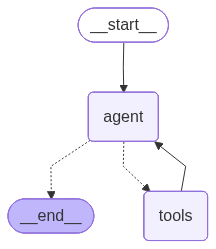

In [7]:
from IPython.display import Image, display

# Desenha o grafo e renderiza como uma imagem PNG
visualizacao = agente_triagem.get_graph().draw_mermaid_png()
display(Image(visualizacao))

## Testando o agent - LangGraph

In [8]:
import time

# Conversa contínua de um mesmo paciente (mesmo cenário crítico)
conversa_paciente = [
    "Oi, preciso de ajuda.",
    "Estou com uma dor insuportável no peito que está descendo pro meu braço esquerdo, me ajuda!",
    "Moro na Avenida Paulista, 1000. Já chamou alguém???"
]

# Definimos uma configuração com um thread_id único para este paciente
config = {"configurable": {"thread_id": "paciente_emergencia_001"}}

print("="*50)
print("INICIANDO ATENDIMENTO CONTÍNUO (Thread: paciente_emergencia_001)\n")

for i, mensagem in enumerate(conversa_paciente, 1):
    print(f"\n--- Turno {i} ---")
    print(f"Paciente: '{mensagem}'\n")
    print("--- Pensamento do Agente ---")

    # Injeta a nova mensagem do usuário
    inputs = {"messages": [("user", mensagem)]}

    # Passamos o 'config' para o stream. Isso garante que o agente
    # recupere o histórico antes de pensar, e salve o novo estado depois.
    for step in agente_triagem.stream(inputs, config=config, stream_mode="updates"):
        for node_name, node_state in step.items():
            ultima_msg = node_state["messages"][-1]

            # Checa se houve chamada de ferramenta
            if hasattr(ultima_msg, 'tool_calls') and ultima_msg.tool_calls:
                ferramenta = ultima_msg.tool_calls[0]['name']
                argumentos = ultima_msg.tool_calls[0]['args']
                print(f"🛠️ Chamou a ferramenta: {ferramenta}")
                print(f"   Parâmetros: {argumentos}")

    print("\n--- Resposta do Agente ---")
    # Captura e imprime a resposta de texto final daquele turno
    if hasattr(ultima_msg, 'content') and ultima_msg.content:
        print(ultima_msg.content)

    time.sleep(5) # Pausa leve entre mensagens do mesmo paciente

INICIANDO ATENDIMENTO CONTÍNUO (Thread: paciente_emergencia_001)


--- Turno 1 ---
Paciente: 'Oi, preciso de ajuda.'

--- Pensamento do Agente ---

--- Resposta do Agente ---
Olá! Sou seu assistente virtual de triagem. Por favor, descreva seus sintomas para que eu possa te ajudar.

--- Turno 2 ---
Paciente: 'Estou com uma dor insuportável no peito que está descendo pro meu braço esquerdo, me ajuda!'

--- Pensamento do Agente ---
🛠️ Chamou a ferramenta: consultar_protocolo_triagem
   Parâmetros: {}

--- Resposta do Agente ---
[{'type': 'text', 'text': 'Isso é uma emergência absoluta! Seus sintomas indicam uma situação muito grave. Preciso acionar uma ambulância imediatamente. Por favor, me diga o endereço completo onde você está.', 'extras': {'signature': 'Cv4FAQw51sfVbNVvNYehWI27AEc4/LWdGkKjq5t2HYszE6N81LFDydYf1EuefhmWTqXSxWUmyLCvN4CCOIHGM4FYlZP4UlGtTNT8rckzMrP0rce1uBCWzI3khm92FmFGFTZQa9Ws4p7O0p4bDYEX5cGPS34na49XnvI+BoDNBHelmUuq6+sPH4L6KfUdb3JeNhsnnKxmIHKW/D40OO6XbpqLMO4kduD8xBEmiJ/xWC